In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from matplotlib.patches import Ellipse

# Configuración
np.random.seed(42)
# sns.set(style="whitegrid")

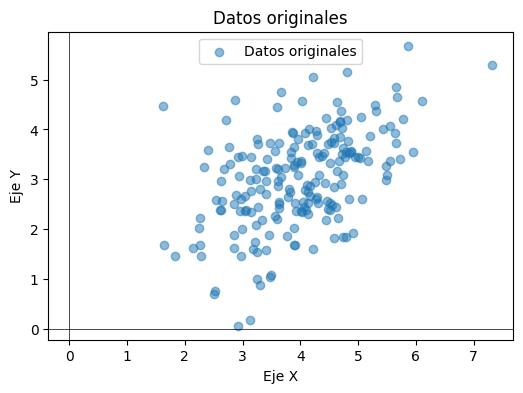

In [2]:
#en la siguiente grafica poner los nombres de los ejes :  # Generar datos con distribución normal
mean = [4, 3]
cov = [[1, 0.5], [0.5, 1]]  # Matriz de covarianza
data = np.random.multivariate_normal(mean, cov, 200)

# Gráfica 1: Datos iniciales
plt.figure(figsize=(6, 4))
plt.scatter(data[:, 0], data[:, 1], alpha=0.5, label="Datos originales")
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.title("Datos originales")
plt.xlabel("Eje X")  # Nombre del eje X
plt.ylabel("Eje Y")  # Nombre del eje Y
plt.legend()
plt.show()

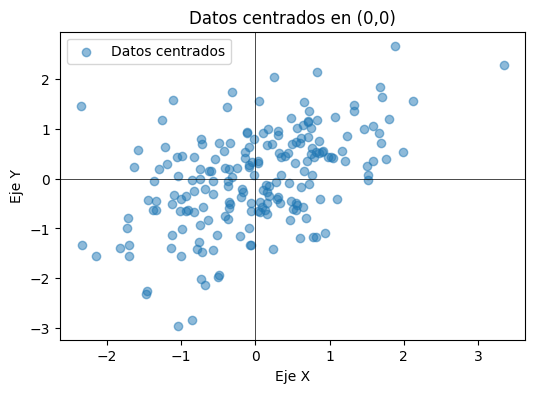

In [3]:
# Centrar los datos (restar la media)
data_centered = data - np.mean(data, axis=0)

# Gráfica 2: Datos centrados
plt.figure(figsize=(6, 4))
plt.scatter(data_centered[:, 0], data_centered[:, 1], alpha=0.5, label="Datos centrados")
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.title("Datos centrados en (0,0)")
plt.xlabel("Eje X")  # Nombre del eje X
plt.ylabel("Eje Y")  # Nombre del eje Y
plt.legend()
plt.show()

In [4]:
# Calcular la matriz de covarianza
cov_matrix = np.cov(data_centered, rowvar=False)
print("Matriz de covarianza:")
print(cov_matrix)

Matriz de covarianza:
[[0.89822318 0.45526185]
 [0.45526185 0.9433956 ]]


Eigenvalores:
[0.46498762 1.37663117]
Eigenvectores:
[[-0.72441374 -0.68936546]
 [ 0.68936546 -0.72441374]]


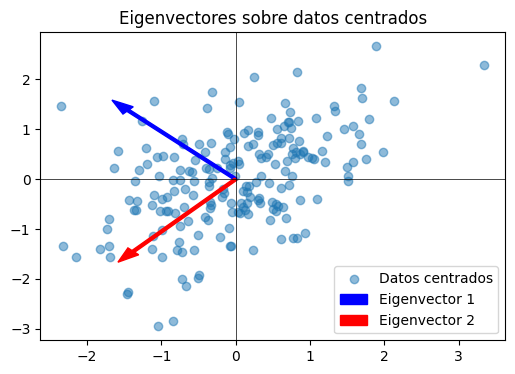

In [5]:
# Calcular eigenvalores y eigenvectores
eigvals, eigvecs = np.linalg.eig(cov_matrix)
print("Eigenvalores:")
print(eigvals)
print("Eigenvectores:")
print(eigvecs)

# Gráfica de eigenvectores sobre los datos centrados
plt.figure(figsize=(6, 4))
plt.scatter(data_centered[:, 0], data_centered[:, 1], alpha=0.5, label="Datos centrados")
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
for i in range(len(eigvals)):
    plt.arrow(0, 0, eigvecs[0, i] * 2, eigvecs[1, i] * 2, color=['blue', 'red'][i], width=0.05, head_width=0.2, label=f"Eigenvector {i+1}")

plt.title("Eigenvectores sobre datos centrados")
plt.legend()
plt.show()

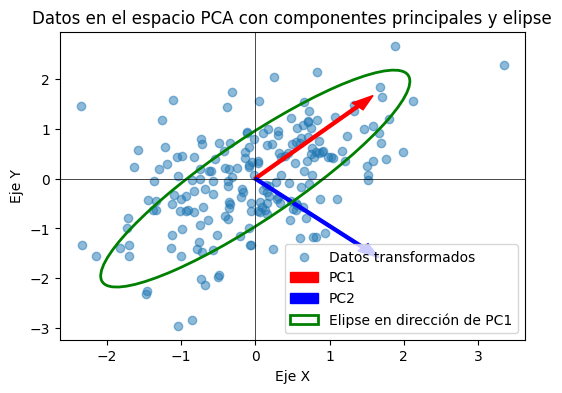

In [7]:
# Aplicar PCA
pca = PCA(n_components=2)
pca.fit(data_centered)
data_pca = pca.transform(data_centered)

# Obtener los vectores de los componentes principales
components = pca.components_
mean_centered = np.mean(data_centered, axis=0)
explained_variances = pca.explained_variance_

# Gráfica 3: Datos en el espacio de los componentes principales con vectores y elipse
plt.figure(figsize=(6, 4))
plt.scatter(data_centered[:, 0], data_centered[:, 1], alpha=0.5, label="Datos transformados")
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
for i, comp in enumerate(components):
    plt.arrow(mean_centered[0], mean_centered[1], comp[0]*2, comp[1]*2, 
              color=['red', 'blue'][i], width=0.05, head_width=0.2, label=f"PC{i+1}")

# Dibujar la elipse en la dirección de PC1
angle = np.degrees(np.arctan2(components[0, 1], components[0, 0]))
ellipse = Ellipse(xy=(0, 0), width=5*np.sqrt(explained_variances[0]), height=2*np.sqrt(explained_variances[1]), 
                  angle=angle, edgecolor='green', facecolor='none', linewidth=2, label="Elipse en dirección de PC1")
plt.gca().add_patch(ellipse)

plt.title("Datos en el espacio PCA con componentes principales y elipse")
plt.xlabel("Eje X")  # Nombre del eje X
plt.ylabel("Eje Y")  # Nombre del eje Y
plt.legend()
plt.show()

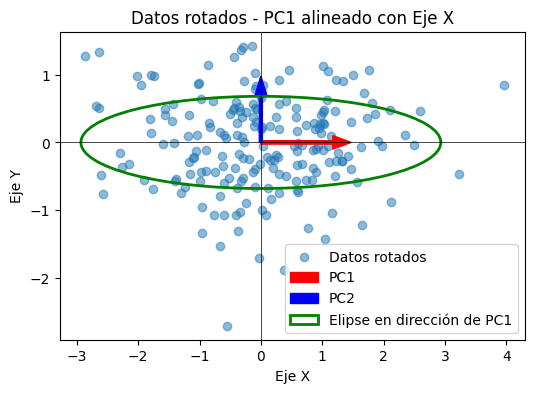

In [8]:
# Gráfica intermedia: Datos rotados para que PC1 coincida con el eje X
plt.figure(figsize=(6, 4))
plt.scatter(data_pca[:, 0], data_pca[:, 1], alpha=0.5, label="Datos rotados")
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
for i in range(2):
    plt.arrow(0, 0, explained_variances[i]**0.5 * (1 if i == 0 else 0), explained_variances[i]**0.5 * (0 if i == 0 else 1),
              color=['red', 'blue'][i], width=0.05, head_width=0.2, label=f"PC{i+1}")

# Dibujar la elipse alineada con PC1
ellipse_rotated = Ellipse(xy=(0, 0), width=5*np.sqrt(explained_variances[0]), height=2*np.sqrt(explained_variances[1]),
                          angle=0, edgecolor='green', facecolor='none', linewidth=2, label="Elipse en dirección de PC1")
plt.gca().add_patch(ellipse_rotated)

plt.title("Datos rotados - PC1 alineado con Eje X")
plt.xlabel("Eje X")  # Nombre del eje X
plt.ylabel("Eje Y")  # Nombre del eje Y
plt.legend()
plt.show()

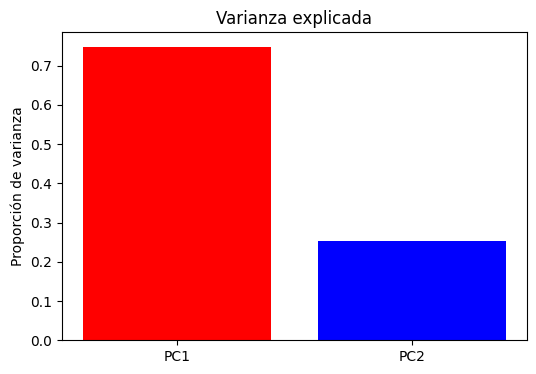

In [11]:
# Gráfica 4: Varianza explicada
plt.figure(figsize=(6, 4))
plt.bar(["PC1", "PC2"], pca.explained_variance_ratio_, color=['red', 'blue'])
plt.title("Varianza explicada")
plt.ylabel("Proporción de varianza")
plt.show()

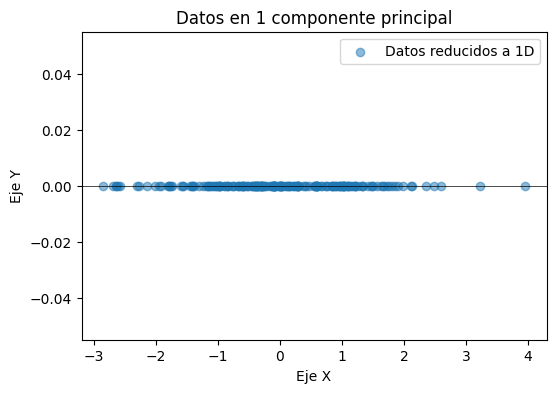

In [12]:
# Reducir a 1 componente principal
pca_1d = PCA(n_components=1)
data_pca_1d = pca_1d.fit_transform(data_centered)

# Gráfica 5: Datos reducidos a 1D
plt.figure(figsize=(6, 4))
plt.scatter(data_pca_1d, np.zeros_like(data_pca_1d), alpha=0.5, label="Datos reducidos a 1D")
plt.axhline(0, color='black', linewidth=0.5)
plt.title("Datos en 1 componente principal")
plt.xlabel("Eje X")  # Nombre del eje X
plt.ylabel("Eje Y")  # Nombre del eje Y
plt.legend()
plt.show()

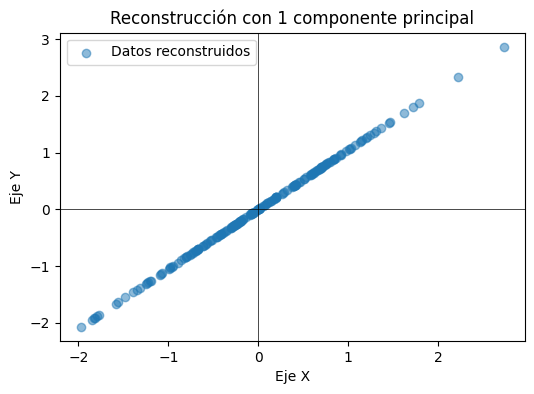

In [13]:
# Reconstrucción con el componente principal
data_reconstructed = pca_1d.inverse_transform(data_pca_1d)

# Gráfica 6: Datos reconstruidos
plt.figure(figsize=(6, 4))
plt.scatter(data_reconstructed[:, 0], data_reconstructed[:, 1], alpha=0.5, label="Datos reconstruidos")
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.title("Reconstrucción con 1 componente principal")
plt.xlabel("Eje X")  # Nombre del eje X
plt.ylabel("Eje Y")  # Nombre del eje Y
plt.legend()
plt.show()